In [1]:
from PIL import Image
import os
from matplotlib import pyplot as plt
import numpy as np
import cv2

In [19]:
import numpy as np

rng = np.random.default_rng(seed=42)   # fixed seed
perm = rng.permutation(1764)  

In [1]:
import torch

In [2]:
from torch.cuda.amp import GradScaler
scaler = GradScaler()

c:\Users\ASUS\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\cuda\amp\grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [3]:
weights_input

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## Data CaMau - Hoa

In [1]:
import rasterio

In [5]:
pwd

'e:\\CEI - Carbon Stock\\experiments\\depth-any-canopy'

In [7]:
import os
os.listdir("../data")

['CAMAU_GEDI.tif',
 'Canopy Height',
 'canopyheight',
 'IBims-1.zip',
 'm1455541.zip',
 'S2A_MSIL2A_20240427T032521_N0510_R018_T48QWK_20240427T090350-20251224T030322Z-3-001.zip',
 'Sentinel - Ba Be',
 'Sentinel - Cuc Phuong',
 'Sentinel - Hoang Lien',
 'sentinel-HL.zip']

In [8]:
import rasterio
path = '../data/CAMAU_GEDI.tif'

with rasterio.open(path) as src:
    img = src.read()

print(img.shape)

(13, 2609, 6033)


In [ ]:
2609 // 256

10

In [ ]:
6033 // 256

23

In [9]:
import numpy as np

gedi = img[-1, :, :]
H, W = gedi.shape

n_point = H*W - np.isnan(gedi).sum()
print("Number of GEDI points:", n_point)
print("Percentage:", n_point/(H*W)*100)
print("Mean height:", np.nanmean(gedi))
print("Max height:", np.nanmax(gedi))
print("Min height:", np.nanmin(gedi))

Number of GEDI points: 66462
Percentage: 0.4222464448599014
Mean height: 5.51769326660351
Max height: 90.739998
Min height: 1.2300000190734863


Number of points: 66462
Percentage: 0.4222464448599014
Mean height: 5.5176932666035094
Max height: 90.739998
Min height: 1.2300000190734863
Histogram of tree height values from GEDI data.


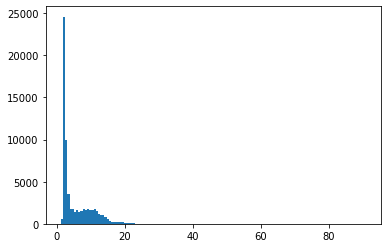

In [10]:
from matplotlib import pyplot as plt

valid_gedi = gedi[~(np.isnan(gedi) | (gedi <= 0))]

valid_gedi = gedi[~np.isnan(gedi)]

n_point = H*W - np.isnan(gedi).sum()
print("Number of points:", n_point)
print("Percentage:", n_point/(H*W)*100)
print("Mean height:", np.nanmean(valid_gedi))
print("Max height:", np.nanmax(valid_gedi))
print("Min height:", np.nanmin(valid_gedi))

# valid_gedi = gedi[~(np.isnan(gedi))]
print("Histogram of tree height values from GEDI data.")
plt.hist(valid_gedi, bins = 140)
plt.show()

Number of points: 66462
Percentage: 0.4222464448599014
Mean height: 5.5176932666035094
Max height: 90.739998
Min height: 1.2300000190734863
Histogram of tree height values from GEDI data.


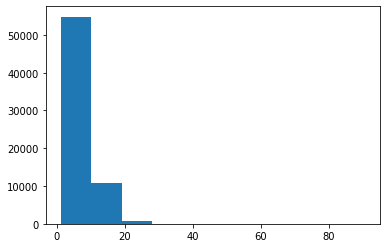

In [11]:
from matplotlib import pyplot as plt

valid_gedi = gedi[~(np.isnan(gedi) | (gedi <= 0))]

valid_gedi = gedi[~np.isnan(gedi)]

n_point = H*W - np.isnan(gedi).sum()
print("Number of points:", n_point)
print("Percentage:", n_point/(H*W)*100)
print("Mean height:", np.nanmean(valid_gedi))
print("Max height:", np.nanmax(valid_gedi))
print("Min height:", np.nanmin(valid_gedi))

# valid_gedi = gedi[~(np.isnan(gedi))]
print("Histogram of tree height values from GEDI data.")
plt.hist(valid_gedi, bins = 10)
plt.show()

Histogram of tree height values from GEDI data.


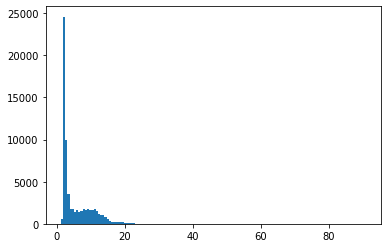

In [12]:
from matplotlib import pyplot as plt

valid_gedi = gedi[~(np.isnan(gedi) | (gedi <= 0))]
print("Histogram of tree height values from GEDI data.")
plt.hist(valid_gedi, bins = 140)
plt.show()

In [13]:
(~np.isnan(gedi)).sum()

66462

A lot of points with value zero. Filtering points with value zero.

In [14]:
gedi = img[-1, :, :]
gedi[gedi <= 0] = np.nan
sentinel = img[:12, :, :]
sentinel.shape

(12, 2609, 6033)

In [15]:
np.isnan(sentinel).sum()

122064

In [16]:
sentinel[np.isnan(sentinel)] = 0

In [22]:
patch_size = 256

n_patch = 10980 // patch_size
cover_rate_map = np.zeros((n_patch, n_patch))
count_map = np.zeros((n_patch, n_patch), dtype=np.int32)
map_gedi = ~np.isnan(gedi)

threshold = 70

count = 0

all_count = 0

n_points = []
noisy_points = []

for i in range(int(H / 256)):
    for j in range(int(W / 256)):
        gedi_patch = gedi[i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size]
        sentinel_path = sentinel[:, i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size]

        # print("Number of points:", np.sum(~np.isnan(gedi_patch)))
        if np.sum(gedi_patch > threshold):
            noisy_points.append(np.sum(gedi_patch > threshold))

            # print("Number of noisy points:", np.sum(gedi_patch > threshold))
            
        n_points.append(np.sum(~np.isnan(gedi_patch)))
        # print(np.nanmax(gedi_patch))
        gedi_patch[gedi_patch > threshold] = np.nan

        # if (gedi_patch > 0).sum() > 50:
        #     count += 1
        all_count += 1
        if (gedi_patch > 0).sum() > 0:
            count += 1

        np.save(f"../data/canopyheight/GEDI_filtered/CaMau/{i*int(W / 256) + j}.npy", gedi_patch)
        np.save(f"../data/canopyheight/Sentinel-12band/CaMau/{i*int(W / 256) + j}.npy", sentinel_path)

In [21]:
all_count

230

In [41]:
os.listdir("../data/canopyheight/GEDI_filtered")

['BaBe', 'CaMau', 'CucPhuong', 'HoangLien']

In [39]:
os.mkdir("../data/canopyheight/Sentinel-12band/CaMau")

In [18]:
np.isnan(gedi_patch).sum()

65536

In [21]:
np.where(~np.isnan(gedi_patch))

(array([], dtype=int64), array([], dtype=int64))

In [8]:
(gedi_patch > 0).sum()

0

In [122]:
int(H / 256) * int(W / 256)

24

In [105]:
sentinel_path.shape

(12, 256, 256)

In [104]:
pwd

'e:\\CEI - Carbon Stock\\experiments\\data\\canopyheight'

In [ ]:
(gedi > threshold).sum()

27

In [62]:
valid_gedi.shape

(44986,)

## GEDI 

### Ba Be

In [25]:
import numpy as np

cn_gedi_babe = np.load("../Canopy Height/ALL_BaBe-NaHang_canopy_height_arr.npy")

In [7]:
n_point = 10980**2 - np.isnan(cn_gedi_babe).sum()
print("Number of GEDI points:", n_point)
print("Percentage:", n_point/10980**2*100)
print("Mean height:", np.nanmean(cn_gedi_babe))
print("Max height:", np.nanmax(cn_gedi_babe))
print("Min height:", np.nanmin(cn_gedi_babe))

Number of GEDI points: 239091
Percentage: 0.19831636258672
Mean height: 25.454145492720414
Max height: 132.75
Min height: 4.11


Histogram of tree height values from GEDI data.


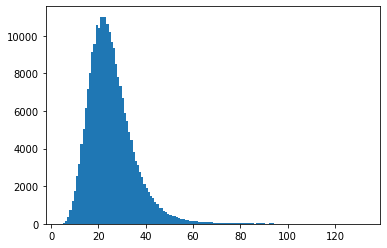

In [12]:
from matplotlib import pyplot as plt

valid_cn_babe = cn_gedi_babe[~np.isnan(cn_gedi_babe)]
print("Histogram of tree height values from GEDI data.")
plt.hist(valid_cn_babe, bins = 140)
plt.show()

In [10]:
os.makedirs("GEDI_filtered_t60/BaBe", exist_ok=True)

In [11]:
patch_size = 256
n_patch = 10980 // patch_size
cover_rate_map = np.zeros((n_patch, n_patch))
count_map = np.zeros((n_patch, n_patch), dtype=np.int32)
map_gedi = ~np.isnan(cn_gedi_babe)
threshold = 60

n_points = []
noisy_points = []

for i in range(n_patch):
    for j in range(n_patch):
        patch = cn_gedi_babe[i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size]

        # print("Number of points:", np.sum(~np.isnan(patch)))
        if np.sum(patch > 60):
            noisy_points.append(np.sum(patch > 60))
        n_points.append(np.sum(~np.isnan(patch)))
        # print(np.nanmax(patch))
        patch[patch > threshold] = np.nan

        np.save(f"GEDI_filtered_t{threshold}/BaBe/{i*n_patch + j}.npy", patch)

In [ ]:
print("Number of noisy points per patch")
plt.hist(noisy_points, bins = 32)
plt.show()

Filtering and saving patched.

Dilated GEDI map.


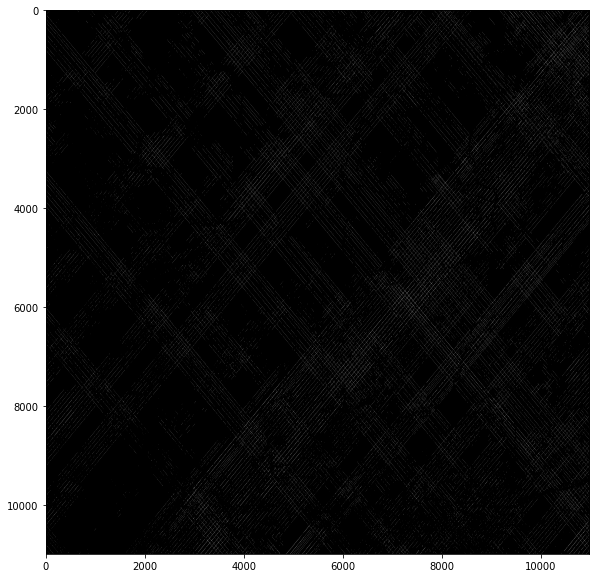

In [26]:
import cv2

k = np.ones((3, 3), np.uint8)
map_gedi = ~np.isnan(cn_gedi_babe)
map_gedi = map_gedi.astype(np.uint8)
dilated_map = cv2.dilate(map_gedi, k, iterations=1)

print("Dilated GEDI map.")
plt.figure(figsize=(12, 10))
plt.imshow(dilated_map, cmap='gray')
plt.show()

Dilated GEDI map.


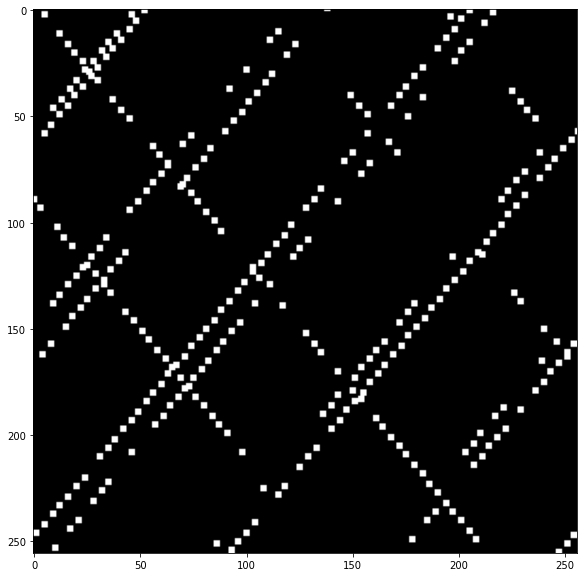

In [27]:
H = 6000
W = 7000

print("Dilated GEDI map.")
plt.figure(figsize=(12, 10))
plt.imshow(dilated_map[H: H+256, W: W+256], cmap='gray')
plt.imsave("dilated_map_patch.png", dilated_map[H: H+256, W: W+256], cmap="gray")
plt.show()

### Hoang Lien

Note: Maximum height of tree in Hoang Lien region is between 50 - 60 meters.  
May filter out the GEDI points higher than that value. They are likely noise.  
The average height is 17.2m, according to Vien Khoa hoc Lam nghiep.

In [6]:
import numpy as np
cn_gedi_hlien = np.load("../Canopy Height/ALL_HoangLien_canopy_height_arr.npy")

n_point = 10980**2 - np.isnan(cn_gedi_hlien).sum()
print("Number of GEDI points:", n_point)
print("Percentage:", n_point/10980**2*100)
print("Mean height:", np.nanmean(cn_gedi_hlien))
print("Max height:", np.nanmax(cn_gedi_hlien))
print("Min height:", np.nanmin(cn_gedi_hlien))

Number of GEDI points: 392468
Percentage: 0.3255364116243808
Mean height: 27.150021887134688
Max height: 145.66
Min height: 4.4


Histogram of tree height values from GEDI data.


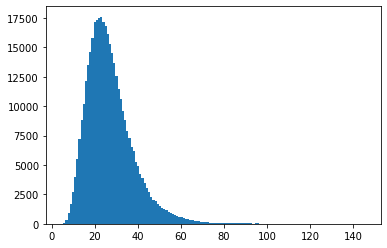

In [13]:
from matplotlib import pyplot as plt

valid_cn_hlien = cn_gedi_hlien[~np.isnan(cn_gedi_hlien)]
print("Histogram of tree height values from GEDI data.")
plt.hist(valid_cn_hlien, bins = 140)
plt.show()

In [68]:
sum(valid_cn > 60)

5187

In [2]:
import os
os.makedirs("GEDI_filtered_t60/HoangLien", exist_ok=True)

In [5]:
n_patch = 10980 // 256
cover_rate_map = np.zeros((n_patch, n_patch))
count_map = np.zeros((n_patch, n_patch), dtype=np.int32)
map_gedi = ~np.isnan(cn_gedi_hlien)
threshold = 60

n_points = []
noisy_points = []

for i in range(n_patch):
    for j in range(n_patch):
        patch = cn_gedi_hlien[i*256: (i+1)*256, j*256: (j+1)*256]

        # print("Number of points:", np.sum(~np.isnan(patch)))
        if np.sum(patch > 60):
            noisy_points.append(np.sum(patch > 60))
        n_points.append(np.sum(~np.isnan(patch)))
        # print(np.nanmax(patch))
        # np.save(f"GEDI/BaBe/{i*n_patch + j}.npy", patch)
        patch[patch > threshold] = np.nan

        np.save(f"GEDI_filtered_t{threshold}/HoangLien/{i*n_patch + j}.npy", patch)

In [ ]:
print("Number of noisy points per patch")
plt.hist(noisy_points, bins = 32)
plt.show()

Dilated GEDI map.


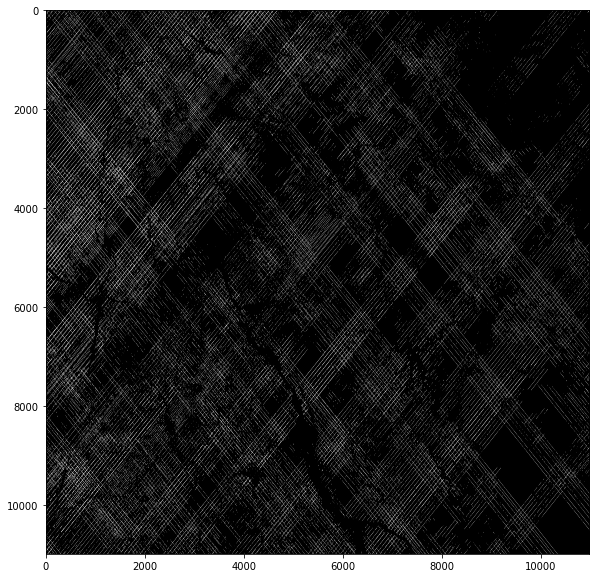

In [7]:
import cv2

k = np.ones((5, 5), np.uint8)
map_gedi = ~np.isnan(cn_gedi_hlien)
map_gedi = map_gedi.astype(np.uint8)
dilated_map = cv2.dilate(map_gedi, k, iterations=1)

print("Dilated GEDI map.")
plt.figure(figsize=(12, 10))
plt.imshow(dilated_map, cmap='gray')
plt.show()

### Cuc Phuong

In [1]:
import numpy as np

cn_gedi_cphg = np.load("../Canopy Height/ALL_CucPhuong_PuLuong_canopy_height_arr.npy")

n_point = 10980**2 - np.isnan(cn_gedi_cphg).sum()
print("Number of GEDI points:", n_point)
print("Percentage:", n_point/10980**2*100)
print("Mean height:", np.nanmean(cn_gedi_cphg))
print("Max height:", np.nanmax(cn_gedi_cphg))
print("Min height:", np.nanmin(cn_gedi_cphg))

Number of GEDI points: 122664
Percentage: 0.10174485154329284
Mean height: 25.721783163764467
Max height: 126.26
Min height: 4.3


Histogram of tree height values from GEDI data.


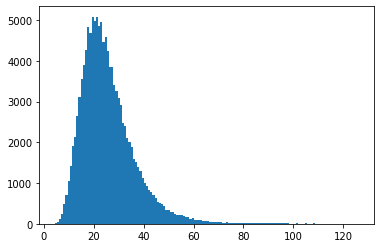

In [15]:
from matplotlib import pyplot as plt

valid_cn_cphg = cn_gedi_cphg[~np.isnan(cn_gedi_cphg)]
print("Histogram of tree height values from GEDI data.")
plt.hist(valid_cn_cphg, bins = 140)
plt.show()

In [72]:
sum(valid_cn > 60)

1479

In [13]:
os.makedirs("GEDI_filtered_t60/CucPhuong", exist_ok=True)

In [14]:
n_patch = 10980 // 256
cover_rate_map = np.zeros((n_patch, n_patch))
count_map = np.zeros((n_patch, n_patch), dtype=np.int32)
map_gedi = ~np.isnan(cn_gedi_cphg)
threshold = 60

n_points = []
noisy_points = []

for i in range(n_patch):
    for j in range(n_patch):
        patch = cn_gedi_cphg[i*256: (i+1)*256, j*256: (j+1)*256]

        # print("Number of points:", np.sum(~np.isnan(patch)))
        if np.sum(patch > 60):
            noisy_points.append(np.sum(patch > 60))
        n_points.append(np.sum(~np.isnan(patch)))
        # print(np.nanmax(patch))
        # np.save(f"GEDI/BaBe/{i*n_patch + j}.npy", patch)

        patch[patch > threshold] = np.nan

        np.save(f"GEDI_filtered_t{threshold}/CucPhuong/{i*n_patch + j}.npy", patch)

Number of noisy points per patch


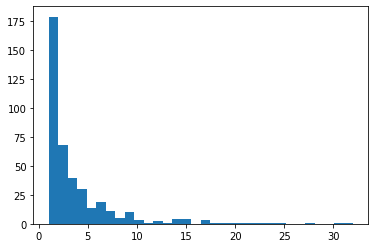

In [25]:
print("Number of noisy points per patch")
plt.hist(noisy_points, bins = 32)
plt.show()

### Other tasks

In [5]:
unique, count = np.unique(n_points, return_counts=True)
n_points = np.array(n_points)

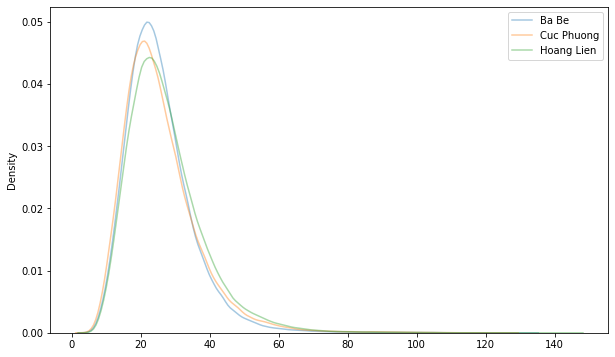

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

cat1 = valid_cn_babe
cat2 = valid_cn_cphg
cat3 = valid_cn_hlien

sns.kdeplot(cat1, label="Ba Be", fill=False, alpha=0.4)
sns.kdeplot(cat2, label="Cuc Phuong", fill=False, alpha=0.4)
sns.kdeplot(cat3, label="Hoang Lien", fill=False, alpha=0.4)

plt.legend()
plt.show()


In [6]:
n_patch**2

1764

In [7]:
np.sum(n_points < 50)

985

In [3]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(n_points, bins=100)
plt.show()

NameError: name 'n_points' is not defined

<Figure size 720x360 with 0 Axes>

In [15]:
for i in [0, 25, 50, 75, 100, 125]:
    print(f"Number ber of patches with more than {i} points: {sum(np.array(n_points) >= i)}")

Number ber of patches with more than 0 points: 1764
Number ber of patches with more than 25 points: 1494
Number ber of patches with more than 50 points: 1348
Number ber of patches with more than 75 points: 1172
Number ber of patches with more than 100 points: 979
Number ber of patches with more than 125 points: 798


In [10]:
patch.shape

(256, 256)

Dilated GEDI map.


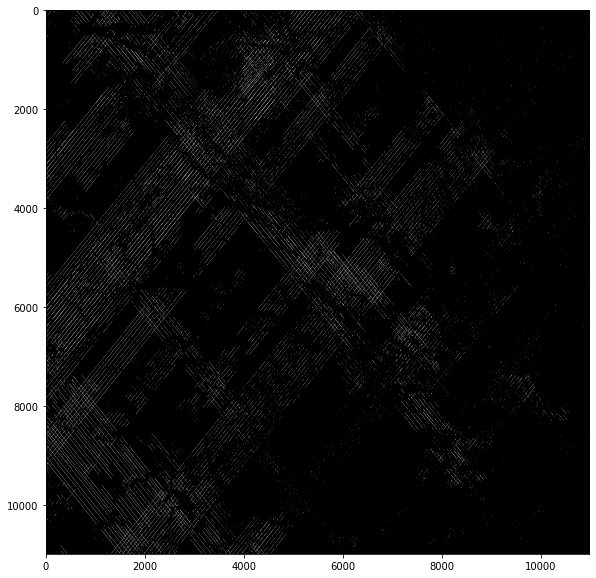

In [5]:
import cv2

k = np.ones((5, 5), np.uint8)
map_gedi = ~np.isnan(cn_gedi_cphg)
map_gedi = map_gedi.astype(np.uint8)
dilated_map = cv2.dilate(map_gedi, k, iterations=1)

print("Dilated GEDI map.")
plt.figure(figsize=(12, 10))
plt.imshow(dilated_map, cmap='gray')
plt.show()

In [140]:
n_patch = 10980 // 256
cover_rate_map = np.zeros((n_patch, n_patch))
count_map = np.zeros((n_patch, n_patch), dtype=np.int32)
map_gedi = ~np.isnan(cn_gedi)

for i in range(n_patch):
    for j in range(n_patch):
        patch = map_gedi[i*256: (i+1)*256, j*256: (j+1)*256]
        cover_rate_map[i, j] = patch.sum() / (256*256) *100
        count_map[i, j] = patch.sum()

In [111]:
map_gedi[:256, :256].sum()

271

In [126]:
cover_rate_map.max()

1.18560791015625

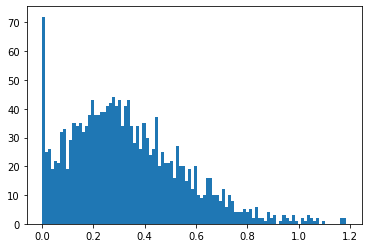

In [132]:
plt.hist(cover_rate_map.flatten(), bins=100)
plt.show()

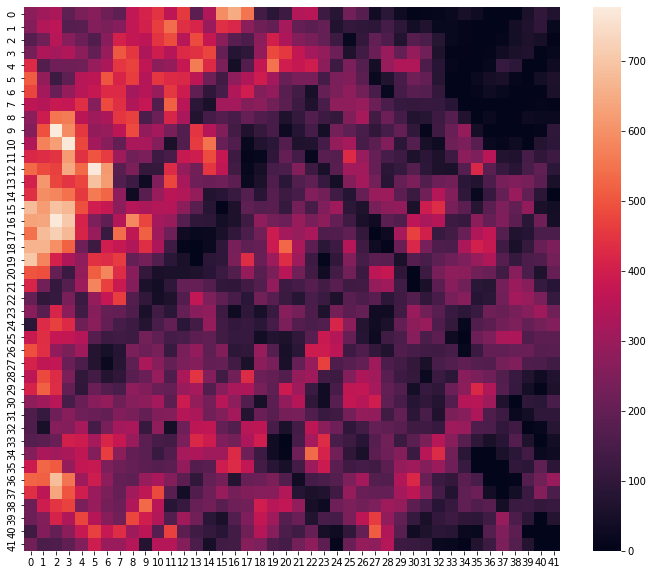

In [141]:
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(count_map)
plt.show()

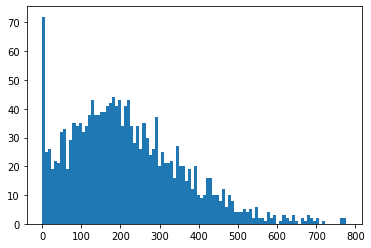

In [143]:
plt.hist(count_map.flatten(), bins=100)
plt.show()

In [ ]:
k = np.ones((5, 5), np.uint8)
map_gedi = ~np.isnan(cn_gedi)
map_gedi = map_gedi.astype(np.uint8)

dilated_map = cv2.dilate(map_gedi, k, iterations=1)

In [209]:
dilated_gridded_map = (~np.isnan(cn_gedi) * 255).astype(np.uint8)
if len(dilated_gridded_map.shape) == 2:  # grayscale
    dilated_gridded_map = cv2.cvtColor(dilated_gridded_map, cv2.COLOR_GRAY2BGR)

In [233]:
dilated_gridded_map = (~np.isnan(cn_gedi) * 255).astype(np.uint8)
# dilated_gridded_map = (dilated_map * 255).astype(np.uint8)


if len(dilated_gridded_map.shape) == 2:
    dilated_gridded_map = cv2.cvtColor(dilated_gridded_map.astype(np.uint8), cv2.COLOR_GRAY2BGR)
else:
    dilated_gridded_map = dilated_gridded_map.astype(np.uint8)

height, width = dilated_gridded_map.shape[:2]
grid_size = 256
color = (0, 255, 0)  # green
thickness = 2
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
text_color = (0, 0, 255)  # red

# Draw vertical lines
for x in range(0, width, grid_size):
    cv2.line(dilated_gridded_map, (x, 0), (x, height), color, thickness)

# Draw horizontal lines
for y in range(0, height, grid_size):
    cv2.line(dilated_gridded_map, (0, y), (width, y), color, thickness)

# Write index on top-left of each cell
rows = height // grid_size
cols = width // grid_size
for i in range(rows):
    for j in range(cols):
        text = f"{i},{j}"  # row,col index
        x_pos = j * grid_size + 10  # small offset from top-left corner
        y_pos = i * grid_size + 25
        cv2.putText(dilated_gridded_map, text, (x_pos, y_pos), font, font_scale, text_color, 1, cv2.LINE_AA)


Dilated GEDI map.


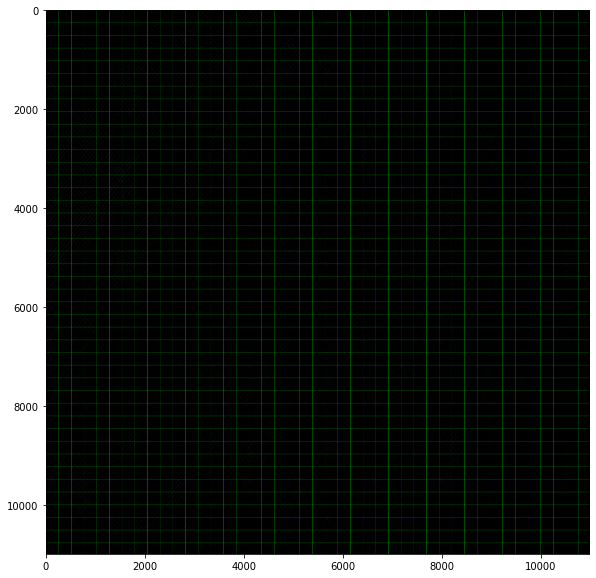

In [234]:
print("Dilated GEDI map.")
plt.figure(figsize=(12, 10))
plt.imshow(dilated_gridded_map)
plt.show()

In [235]:
# cv2.imwrite("gedi_map_dilated_gridded.png", dilated_gridded_map)
cv2.imwrite("gedi_map_gridded.png", dilated_gridded_map)

True

In [ ]:
# Compute unique values and their counts from the loaded array
unique_vals, counts = np.unique(cn_gedi, return_counts=True)
print('Number of unique values:', unique_vals.size)
print('Unique values (first 50):', unique_vals[:50])
print('Counts (first 50):', counts[:50])
# If you want the full arrays, inspect `unique_vals` and `counts`

Number of unique values: 5509
Unique values (first 50): [4.4  4.63 4.67 4.71 4.73 4.75 4.84 4.86 4.9  5.05 5.09 5.11 5.19 5.23
 5.26 5.3  5.34 5.38 5.42 5.46 5.48 5.5  5.53 5.57 5.61 5.65 5.67 5.69
 5.71 5.73 5.75 5.8  5.86 5.88 5.9  5.92 5.94 5.98 6.01 6.03 6.05 6.07
 6.09 6.13 6.17 6.21 6.23 6.25 6.26 6.28]
Counts (first 50): [1 1 1 1 1 2 1 1 1 1 1 1 1 2 1 4 3 1 2 2 1 2 2 4 2 3 2 2 1 4 1 2 2 1 1 2 4
 4 2 4 6 1 7 1 2 5 2 2 2 5]


## Sentinel Image

### Ba Be

In [1]:
import cv2

img_b01 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B01_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b02 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B02_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b03 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B03_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b04 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B04_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b05 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B05_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b06 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B06_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b07 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B07_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b08 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B08_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b08a = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B8A_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b09 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B09_60m.jp2", cv2.IMREAD_UNCHANGED)
img_b11 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B11_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b12 = cv2.imread("../Sentinel - Ba Be/T48QWK_20240427T032521_B12_20m.jp2", cv2.IMREAD_UNCHANGED)


In [3]:
import numpy as np

bands = [img_b01, img_b02, img_b03, img_b04, img_b05,
        img_b06, img_b07, img_b08, img_b08a, img_b09, img_b11, img_b12]
band_names = ["B01", "B02", "B03", "B04", "B05",
        "B06", "B07", "B08", "B08a", "B09", "B11", "B12"]
res = [20, 10, 10, 10, 20, 20, 20, 10, 20, 60, 20, 20]

bands_upsampled = []
for i, b in enumerate(bands):
    b = np.repeat(np.repeat(b, int(res[i] / 10), axis=0), int(res[i]/10), axis=1)
    bands_upsampled.append(b)

In [16]:
import numpy as np 

header = ",".join(band_names)
patch_size = 64
n_patch = 10980 // patch_size

for i in range(n_patch):
    for j in range(n_patch):

        img = np.array([band[i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size] for band in bands_upsampled])
        # print(img.shape)
        img = img.transpose(1, 2, 0)
        
        arr_2d = img.reshape(-1, 12)
        # np.save(f"Sentinel-12band-size64/BaBe/{i*n_patch + j}.npy", img)
        np.savetxt(f"Sentinel-12band-size64-csv/BaBe/{i*n_patch + j}.csv", arr_2d, delimiter=",", header=header, comments="")
        
        if j == 4:
            break
    if i == 4:
        break 


In [19]:
img_b01[:3, :3]

array([[ 931,  928,  926],
       [ 921, 1823, 2119],
       [ 919, 2129, 2443]], dtype=uint16)

In [ ]:
# Reshape: (64, 64, 12) -> (4096, 12)
arr_2d = arr.reshape(-1, 12)


In [15]:
header = ",".join(band_names)

np.savetxt("output.csv", arr_2d, delimiter=",", header=header, comments="")

In [31]:
band_mean_BaBe = []
band_std_BaBe = []

for i,b in enumerate(bands):
    # print("Band: ", band_names[i])
    # print(f"Band shape: {b.shape}; Data type: {b.dtype}; Max: {b.max()}; Min: {b.min()}")
    # print(f"Scaled mean: {b.mean() / b.max()}")
    # print(f"Scaled std: {b.std() / b.max()}")
    band_mean_BaBe.append(b.mean())
    band_std_BaBe.append(b.std())

### Cuc Phuong

In [2]:
import cv2

img_b01 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B01_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b02 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B02_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b03 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B03_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b04 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B04_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b05 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B05_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b06 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B06_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b07 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B07_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b08 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B08_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b08a = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B8A_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b09 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B09_60m.jp2", cv2.IMREAD_UNCHANGED)
img_b11 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B11_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b12 = cv2.imread("../Sentinel - Cuc Phuong/T48QWH_20240212T032849_B12_20m.jp2", cv2.IMREAD_UNCHANGED)


In [23]:
gedi = np.load("GEDI/CucPhuong/0.npy")
cn_gedi_cphg = np.load("../Canopy Height/ALL_CucPhuong_PuLuong_canopy_height_arr.npy")
gedi = cn_gedi_cphg
# gedi = gedi > 0

In [24]:
gedi[np.isnan(gedi)] = 0 

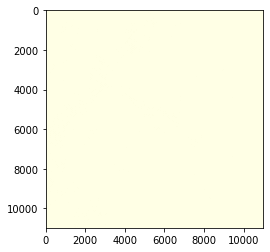

In [28]:
plt.imshow(gedi, cmap='YlGn', vmax=70)

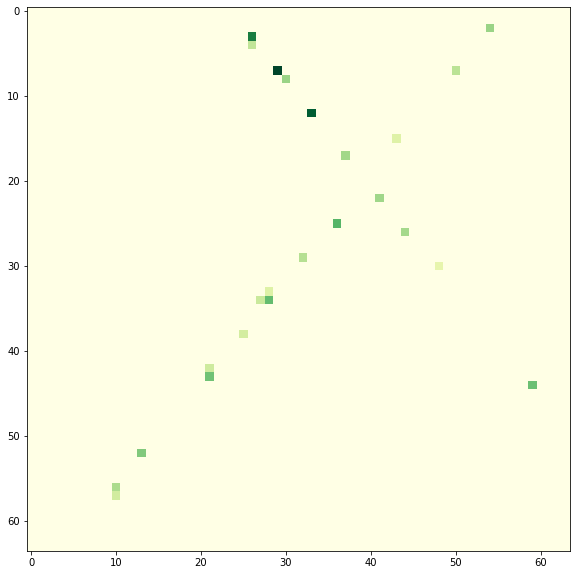

In [36]:
plt.figure(figsize=(12, 10))
H = 3100
W = 3100
plt.imshow(gedi[H:H+64, W:W+64], cmap='YlGn')

Dilated GEDI map.


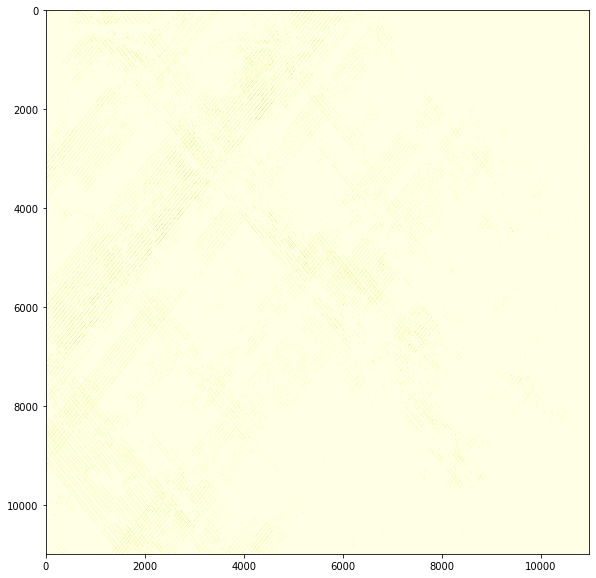

In [16]:
import cv2 

k = np.ones((3, 3), np.uint8)
map_gedi = ~np.isnan(gedi)
map_gedi = map_gedi.astype(np.uint8)
dilated_map = cv2.dilate(map_gedi, k, iterations=1)

print("Dilated GEDI map.")
plt.figure(figsize=(12, 10))
plt.imshow(dilated_map, cmap='YlGn')
plt.show()

In [15]:
plt.imshow(dilated_map[H: H+256, W: W+256] * img[8, :, :])
plt.imsave("dilated_gedi_overlay.png", dilated_map[H: H+256, W: W+256] * img[8, :, :])

NameError: name 'H' is not defined

Dilated GEDI map.


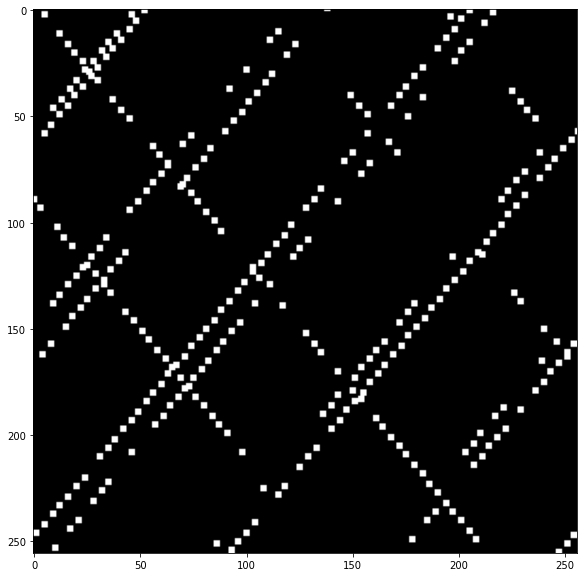

In [ ]:
print("Dilated GEDI map.")
plt.figure(figsize=(12, 10))
plt.imshow(dilated_map[H: H+256, W: W+256], cmap='gray')
plt.show()

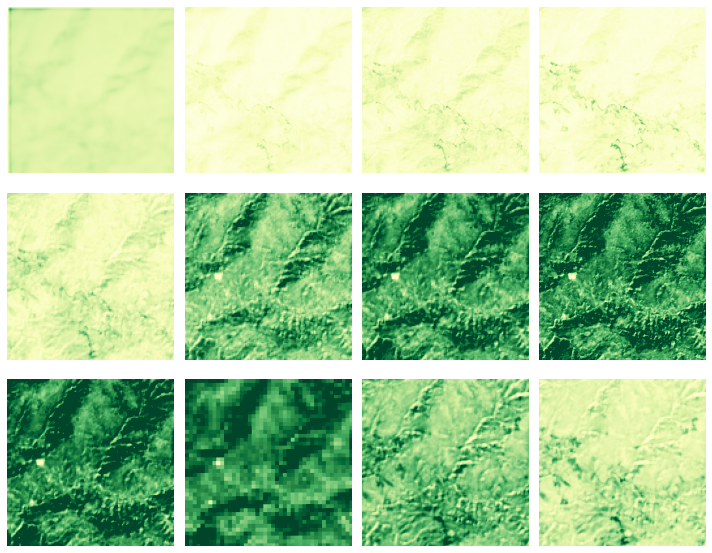

In [9]:
import matplotlib.pyplot as plt
import numpy as np

img = np.load("Sentinel-12band/CucPhuong/0.npy")


# Example: create 12 random grayscale images (replace with your images)
images = [np.random.rand(64, 64) for _ in range(12)]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(img[i, :, :], cmap='YlGn', vmax=4200)
    # ax.imshow(img[i, :, :])
    ax.axis('off')  # hide axis

    plt.imsave(f"band{i}_color.png", img[i, :, :], cmap='YlGn', vmax=4200)

plt.tight_layout()
plt.show()

In [3]:
img[i, :, :].max()

4293

In [1]:
a = 1

In [28]:
band_mean_CP = []
band_std_CP = []

for i,b in enumerate(bands):
    # print("Band: ", band_names[i])
    # print(f"Band shape: {b.shape}; Data type: {b.dtype}; Max: {b.max()}; Min: {b.min()}")
    # print(f"Scaled mean: {b.mean() / b.max()}")
    # print(f"Scaled std: {b.std() / b.max()}")
    band_mean_CP.append(b.mean())
    band_std_CP.append(b.std())

In [4]:
import numpy as np

bands = [img_b01, img_b02, img_b03, img_b04, img_b05,
        img_b06, img_b07, img_b08, img_b08a, img_b09, img_b11, img_b12]
band_names = ["B01", "B02", "B03", "B04", "B05",
        "B06", "B07", "B08", "B08a", "B09", "B11", "B12"]
res = [20, 10, 10, 10, 20, 20, 20, 10, 20, 60, 20, 20]

bands_upsampled = []
for i, b in enumerate(bands):
    b = np.repeat(np.repeat(b, int(res[i] / 10), axis=0), int(res[i]/10), axis=1)
    bands_upsampled.append(b)

In [5]:
import numpy as np 

patch_size = 64
n_patch = 10980 // patch_size

for i in range(n_patch):
    for j in range(n_patch):
        patch_b02 = img_b02[i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size] # Blue
        patch_b03 = img_b03[i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size] # Green
        patch_b04 = img_b04[i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size] # Red

        img = np.array([band[i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size] for band in bands_upsampled])
        # print(img.shape)
        # img = img.transpose(1, 2, 0)
        
        np.save(f"Sentinel-12band-size64/CucPhuong/{i*n_patch + j}.npy", img)
        
        if j == 4:
            break
    if i == 4:
        break 


In [15]:
print("Band max:", band_max)
print("Band min:", band_min)
print("Band mean:", band_mean)
print("Band std:", band_std)

Band max: [9715, 14832, 19088, 20672, 18698, 19224, 17149, 18737, 18366, 11594, 16754, 16495]
Band min: [595, 948, 1155, 1037, 953, 978, 699, 1062, 603, 1136, 1112, 925]
Band mean: [1520.6609315164847, 1510.073361393957, 1725.8952688196125, 1549.054587700439, 2081.962455731733, 3566.2657906576287, 4038.8862492825174, 4090.1853575054497, 4286.104002773714, 4268.008437098749, 3212.220851556564, 2183.6028525452803]
Band std: [162.89795751683212, 172.58777840186895, 194.71679850839678, 260.6577525489719, 265.5037872089045, 475.28586462857436, 569.8535671636575, 614.2131652983157, 607.2421943203072, 503.7947345700351, 511.57328175486384, 444.4480076245513]


In [ ]:
import numpy as np 

n_patch = 10980 // 256

for i in range(n_patch):
    for j in range(n_patch):
        patch_b02 = img_b02[i*256: (i+1)*256, j*256: (j+1)*256] # Blue
        patch_b03 = img_b03[i*256: (i+1)*256, j*256: (j+1)*256] # Green
        patch_b04 = img_b04[i*256: (i+1)*256, j*256: (j+1)*256] # Red

        img = np.array([band[i*256: (i+1)*256, j*256: (j+1)*256] for band in bands_upsampled])
        print(img.shape)
        break
        # img = img.transpose(1, 2, 0)
        
        # np.save(f"Sentinel/BaBe/{i*n_patch + j}.npy", img)


In [50]:
np.array([band[i*256: (i+1)*256, j*256: (j+1)*256] for band in bands_upsampled]).shape

(12, 256, 256)

### Hoang Lien

In [2]:
import cv2

img_b01 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B01_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b02 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B02_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b03 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B03_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b04 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B04_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b05 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B05_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b06 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B06_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b07 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B07_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b08 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B08_10m.jp2", cv2.IMREAD_UNCHANGED)
img_b08a = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B8A_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b09 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B09_60m.jp2", cv2.IMREAD_UNCHANGED)
img_b11 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B11_20m.jp2", cv2.IMREAD_UNCHANGED)
img_b12 = cv2.imread("../Sentinel - Hoang Lien/T48QUK_20240306T033609_B12_20m.jp2", cv2.IMREAD_UNCHANGED)


In [3]:
import numpy as np

bands = [img_b01, img_b02, img_b03, img_b04, img_b05,
        img_b06, img_b07, img_b08, img_b08a, img_b09, img_b11, img_b12]
band_names = ["B01", "B02", "B03", "B04", "B05",
        "B06", "B07", "B08", "B08a", "B09", "B11", "B12"]
res = [20, 10, 10, 10, 20, 20, 20, 10, 20, 60, 20, 20]

bands_upsampled = []
for i, b in enumerate(bands):
    b = np.repeat(np.repeat(b, int(res[i] / 10), axis=0), int(res[i]/10), axis=1)
    bands_upsampled.append(b)

In [8]:
import numpy as np 

header = ",".join(band_names)
patch_size = 256
n_patch = 10980 // patch_size

for i in range(n_patch):
    for j in range(n_patch):

        img = np.array([band[i*patch_size: (i+1)*patch_size, j*patch_size: (j+1)*patch_size] for band in bands_upsampled])
        # print(img.shape)
        # img = img.transpose(1, 2, 0)
        
        arr_2d = img.reshape(-1, 12)
        np.save(f"Sentinel-12band/HoangLien/{i*n_patch + j}.npy", img)
        # np.savetxt(f"Sentinel-12band-size64-csv/BaBe/{i*n_patch + j}.csv", arr_2d, delimiter=",", header=header, comments="")
        



In [2]:
import numpy as np
np.load("Sentinel-12band/HoangLien/0.npy").shape

(12, 256, 256)

In [4]:
np.load("Sentinel-12band/CucPhuong/0.npy").shape

(12, 256, 256)